# 3. Feature Engineering

In this notebook, we progressively introduce and analyze chess position features. We start with basic piece counts and gradually add more sophisticated features like pawn structure, king safety, mobility, board control, and tactical relationships.

For each feature bundle, we:
1. Explain the chess concept behind the features
2. Extract the features using our transformers
3. Analyze correlations between features
4. Visualize feature distributions
5. Check correlation with the target variable (Evaluation)

By doing this, we can eventually compare all feature groups and see which ones truly matter the most. In the end, we’ll be able to pinpoint the features that have the strongest impact on the evaluation.


**Note**: We are not training models yet - that comes in later notebooks. Here we focus purely on understanding our features.

In [1]:
from chess_eval import *
import seaborn as sns

## Helper Functions

In [2]:
def analyze_features(dm, feature_bundle):
    """
    Analyze a feature bundle: correlations with target and basic statistics.
    
    Parameters
    ----------
    dm : DataManager
        DataManager with features
    feature_bundle : FeatureBundle class
        The feature bundle to analyze
    """
    features = list(feature_bundle.features)
    
    print(f"\n{'='*70}")
    print(f"{feature_bundle.name}")
    print(f"{len(features)} features")
    print(f"{'='*70}\n")
    
    feature_data = dm.df[features]
    
    # Correlation with Evaluation (target variable)
    eval_corr = dm.df[features + [EVAL]].corr()[EVAL].drop(EVAL).sort_values(ascending=False)
    
    print("Correlation with Evaluation (sorted by absolute value):\n")
    corr_sorted = eval_corr.abs().sort_values(ascending=False)
    for feat in corr_sorted.index:
        corr_val = eval_corr[feat]
        print(f"  {feat:40s} {corr_val:6.3f}")
    
    # Plot 1: Correlation with Evaluation
    fig1, ax1 = plt.subplots(figsize=(12, max(8, len(features) * 0.35)))  # type: ignore
    
    colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in eval_corr]
    y_pos = np.arange(len(eval_corr))
    
    ax1.barh(y_pos, eval_corr.values, color=colors, alpha=0.75, edgecolor='black', linewidth=0.5)
    ax1.set_yticks(y_pos)
    ax1.set_yticklabels(eval_corr.index, fontsize=10)
    ax1.axvline(x=0, color='black', linewidth=1.5, linestyle='-')
    ax1.set_xlabel('Correlation with Evaluation', fontsize=12, fontweight='bold')
    ax1.set_title(f'{feature_bundle.name} - Correlation with Target', 
                  fontsize=14, fontweight='bold', pad=20)
    ax1.grid(axis='x', alpha=0.3, linestyle='--')
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    
    plt.tight_layout()
    plt.show()
    
    # Plot 2: Feature correlation heatmap
    corr_matrix = feature_data.corr()
    n_features = len(features)
    
    figsize = max(10, n_features * 0.6)
    fig2, ax2 = plt.subplots(figsize=(figsize, figsize))
    
    if n_features <= 15:
        sns.heatmap(corr_matrix, annot=True, fmt='.2f', 
                    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                    square=True, linewidths=1, linecolor='white',
                    cbar_kws={"shrink": 0.8, "label": "Correlation"},
                    ax=ax2, annot_kws={'fontsize': 10})
    elif n_features <= 25:
        sns.heatmap(corr_matrix, annot=True, fmt='.2f',
                    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                    square=True, linewidths=0.5, linecolor='white',
                    cbar_kws={"shrink": 0.8, "label": "Correlation"},
                    ax=ax2, annot_kws={'fontsize': 8})
    else:
        sns.heatmap(corr_matrix, annot=False,
                    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                    square=True, linewidths=0,
                    cbar_kws={"shrink": 0.8, "label": "Correlation"},
                    ax=ax2)
    
    ax2.set_title(f'{feature_bundle.name} - Feature Intercorrelations', 
                  fontsize=14, fontweight='bold', pad=20)
    
    ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right', fontsize=9)
    ax2.set_yticklabels(ax2.get_yticklabels(), rotation=0, fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    # Basic statistics table
    print("\n\nFeature Statistics:\n")
    stats = feature_data.describe().T[['mean', 'std', 'min', 'max']]
    print(stats.to_string())
    
    # Print full intercorrelation matrix (text format)
    print("\n\nFeature Intercorrelation Matrix:\n")
    print(corr_matrix.to_string(float_format=lambda x: f"{x:6.3f}"))
    
    print("\n" + "="*70 + "\n")

## Load Data

We'll work with a sample to quickly analyze features.

In [3]:
# Create DataManager without transformers initially
dm = DataManager(
    read_size=500_000,
    sample_size=100_000,
    transformers=[],  # We'll add them one by one
)

print(f"Dataset shape: {dm.df.shape}")
print(f"Evaluation range: [{dm.df[EVAL].min()}, {dm.df[EVAL].max()}]")
print(f"Evaluation mean: {dm.df[EVAL].mean():.2f}")
dm.df.head()

Dataset shape: (100000, 2)
Evaluation range: [-1000, 1000]
Evaluation mean: 28.38


,FEN,Evaluation
0,1rb2rk1/p1p1qppp/2P2b2/8/2p1B3/2N1P1P1/P4P1P/R...,-92
1,8/6k1/8/P5p1/3nB3/7P/8/6K1 b - - 0 47,419
2,r2qr1k1/p1p2ppp/1p1bpn2/6B1/3P4/2P2N2/PP2QPPP/...,113
3,3bqrk1/1pp1n1p1/1p2p3/1N2Pb1p/1PP5/P3QN1P/4B1P...,102
4,2r1kb1r/1p1q2pp/1pnPpp2/pN2Pb2/Q1P5/P4N2/1P4PP...,286


## 1. Piece Information

The most natural indicator to predict player advantage is **piece count**: how many pieces does each player have? 

The `PieceInfo` transformer extracts:
- **Total piece counts** for white and black
- **Individual piece type counts** (pawns, knights, bishops, rooks, queens)
- **Total material value** using standard piece values (♙=1, ♘=3, ♗=3, ♜=5, ♛=9)
- **Central piece control** (pieces on d4, d5, e4, e5)

Material advantage is the most fundamental concept in chess evaluation.


Piece Information
16 features

Correlation with Evaluation (sorted by absolute value):

  White_Pawn                                0.112
  White_Pieces                              0.091
  White_Central_Pieces                      0.085
  White_Piece_Value                         0.076
  White_Rook                                0.059
  White_Bishop                              0.057
  White_Queen                               0.056
  Black_Central_Pieces                     -0.055
  Black_Knight                              0.043
  Black_Pawn                               -0.042
  Black_Rook                                0.025
  Black_Queen                               0.023
  Black_Piece_Value                         0.021
  White_Knight                              0.005
  Black_Pieces                             -0.002
  Black_Bishop                              0.002


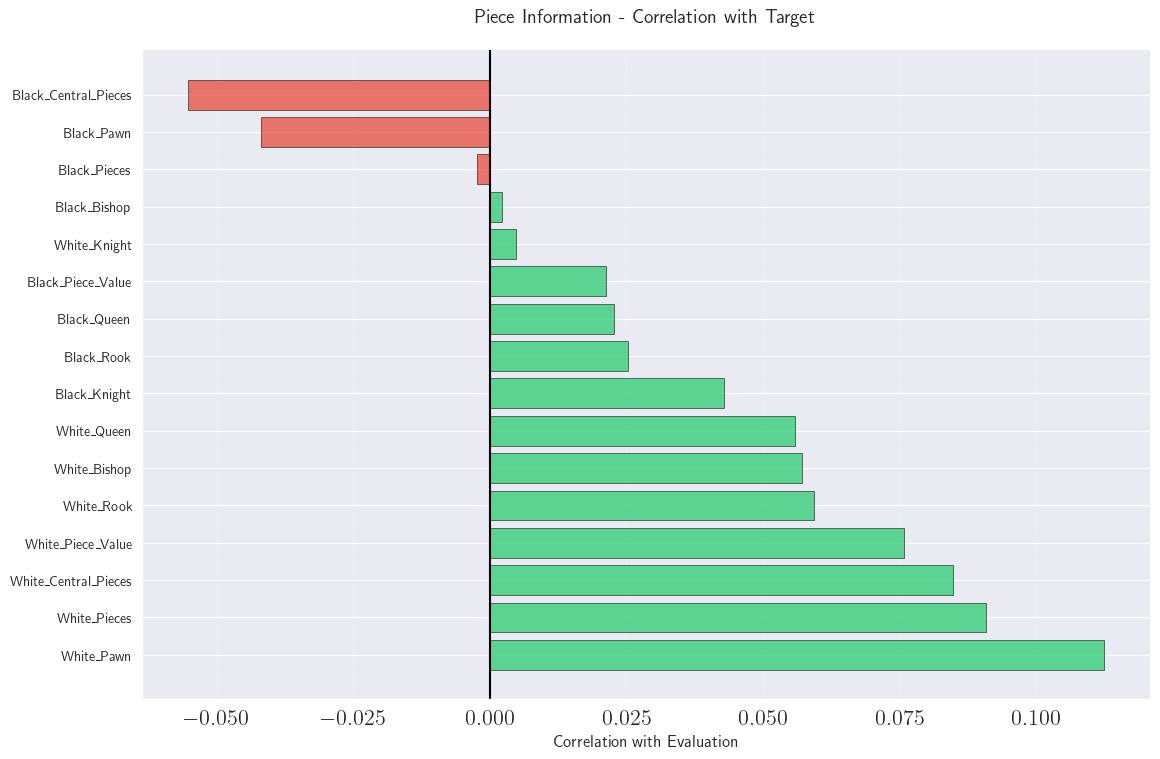

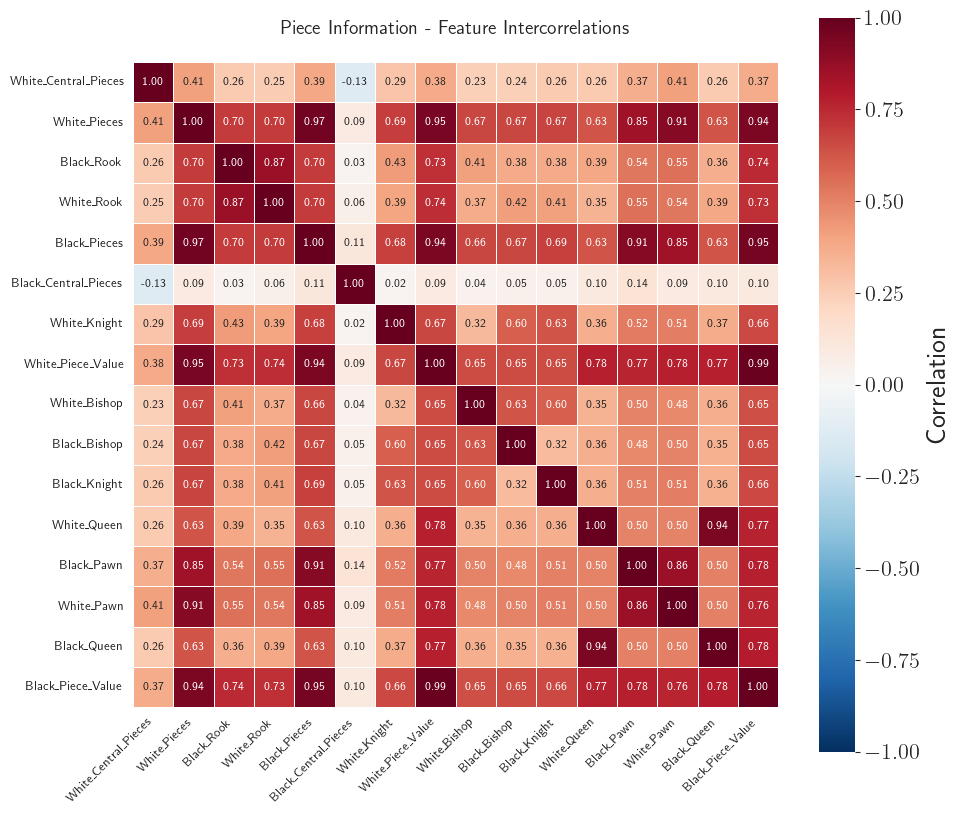



Feature Statistics:

                          mean        std  min   max
White_Central_Pieces   0.93424   0.764213  0.0   4.0
White_Pieces          10.61478   3.375372  1.0  16.0
Black_Rook             1.53034   0.674021  0.0   2.0
White_Rook             1.52760   0.674924  0.0   2.0
Black_Pieces          10.68339   3.355378  1.0  16.0
Black_Central_Pieces   0.59241   0.640394  0.0   4.0
White_Knight           0.91455   0.767512  0.0   2.0
White_Piece_Value     24.90122  10.221594  0.0  42.0
White_Bishop           1.08515   0.772066  0.0   2.0
Black_Bishop           1.02630   0.769139  0.0   2.0
Black_Knight           0.97293   0.772854  0.0   2.0
White_Queen            0.64708   0.478132  0.0   2.0
Black_Pawn             5.51062   1.689365  0.0   8.0
White_Pawn             5.44040   1.711577  0.0   8.0
Black_Queen            0.64320   0.479120  0.0   2.0
Black_Piece_Value     24.94881  10.227188  0.0  40.0


Feature Intercorrelation Matrix:

                      White_Central_Piec

In [4]:
# Apply PieceInfo transformer
dm.apply_transformers([PieceInfo])

# Analyze features
analyze_features(dm, PieceInfo)

### Observations on Piece-Related Features

**1. Correlation with Evaluation**
The correlations with the target (Evaluation) are generally *weak*, with all absolute values below 0.12.  
The strongest positive relationships come from **White-side piece counts**, especially:

- **White_Pawn** (0.112)  
- **White_Pieces** (0.091)  
- **White_Central_Pieces** (0.085)  
- **White_Piece_Value** (0.076)

This suggests that **having more white material or activity tends to slightly increase the evaluation score**.  
On the Black side, the only notable signal is:

- **Black_Central_Pieces** (-0.055)

indicating a *slightly negative* effect on evaluation when Black controls central squares.

What seems contradictory is that features relating **Black-side information** (5 out of 8) go along with the evaluation, as they have a positive correlation with target. For now, this is not concerning, as intuitively does not have any significance and the correlation is actually slight. This information just only tells us that our dataset is slightly unbalanced again, favoring white-side players. It is important to remark that correlation does not implicate causation, **correlation implies how strongly two variables move together and in what direction**.

Overall, **no piece-count feature is strongly predictive on its own**, as the pearson-correlation lives in [-1,1],  which means evaluation likely depends on more complex positional or tactical factors not captured purely by material counts.

---

**2. Feature Statistics**
The descriptive statistics show that:
- All piece counts fall within expected ranges (0–8 for pawns, 0–2 for minors/rooks/queens).
- Mean values align well with typical midgame positions (e.g., ~5.5 pawns, ~1 of each minor piece on average).
- Standard deviations indicate healthy variability across samples.
- No strange outliers or impossible values appear.

This confirms the dataset is **clean and well-behaved** for modeling.

---

**3. Intercorrelation Heatmap**  
The heatmap mainly reflects expected structural relationships among the features:

- Features counting *Color_Piece_Value* and *Color_Pieces* show the **strongest positive correlations**, with Black_Piece_Value and White_Piece_Value reaching as high as 0.99.  
- *Color_Pawn* exhibits high correlations with most other pieces, reflecting its contribution to total material.  
- *Black_Central_Pieces* shows near-zero correlation with all other features, indicating that central control behaves largely independently from raw material counts.  
- There are notable correlations between pieces of the same type but opposite colors, e.g., *White_Queen* vs. *Black_Queen*, *White_Pawn* vs. *Black_Pawn*, and *White_Rook* vs. *Black_Rook*. This likely reflects typical game positions where the presence of one side's piece is mirrored or balanced by the corresponding piece of the opponent.
- No pair of features is perfectly redundant. Although strong group patterns appear, no correlations reach 1.0 (except the diagonal), so no features are exact duplicates.
- Nearly all features have **positive correlations**, with very few negative values.  
    - This indicates that most features **increase together** rather than in opposition.  
    - In chess terms, it suggests that positions with more pieces or higher material for one side often coincide with more material for the other side, reflecting typical midgame positions rather than extreme imbalances.  
    - Overall, the dataset captures **positively structured material and piece distributions**, where evaluation is driven by cumulative presence and activity of pieces rather than strict trade-offs.

---

Having analyzed PieceInfo, we can now proceed to add more feature bundles and analyze them similarly.

## 2. Pawn Structure

Pawns form the **skeleton of chess positions**. The `PawnStructure` transformer captures:

- **Isolated pawns**: Pawns with no friendly pawns on adjacent files (weakness)
- **Doubled pawns**: Multiple pawns on the same file (weakness)
- **Passed pawns**: Pawns with no enemy pawns blocking their advance (strength)
- **Pawn islands**: Connected groups of pawns (fewer is better)

These features capture long-term positional weaknesses and strengths that material count alone cannot measure. Pawn structure often determines the character of the position.


Pawn Structure
8 features

Correlation with Evaluation (sorted by absolute value):

  Passed_Pawns_Black                       -0.150
  Passed_Pawns_White                        0.128
  Isolated_Pawns_White                     -0.043
  Pawn_Islands_White                        0.035
  Doubled_Pawns_White                       0.023
  Isolated_Pawns_Black                      0.021
  Doubled_Pawns_Black                      -0.018
  Pawn_Islands_Black                       -0.009


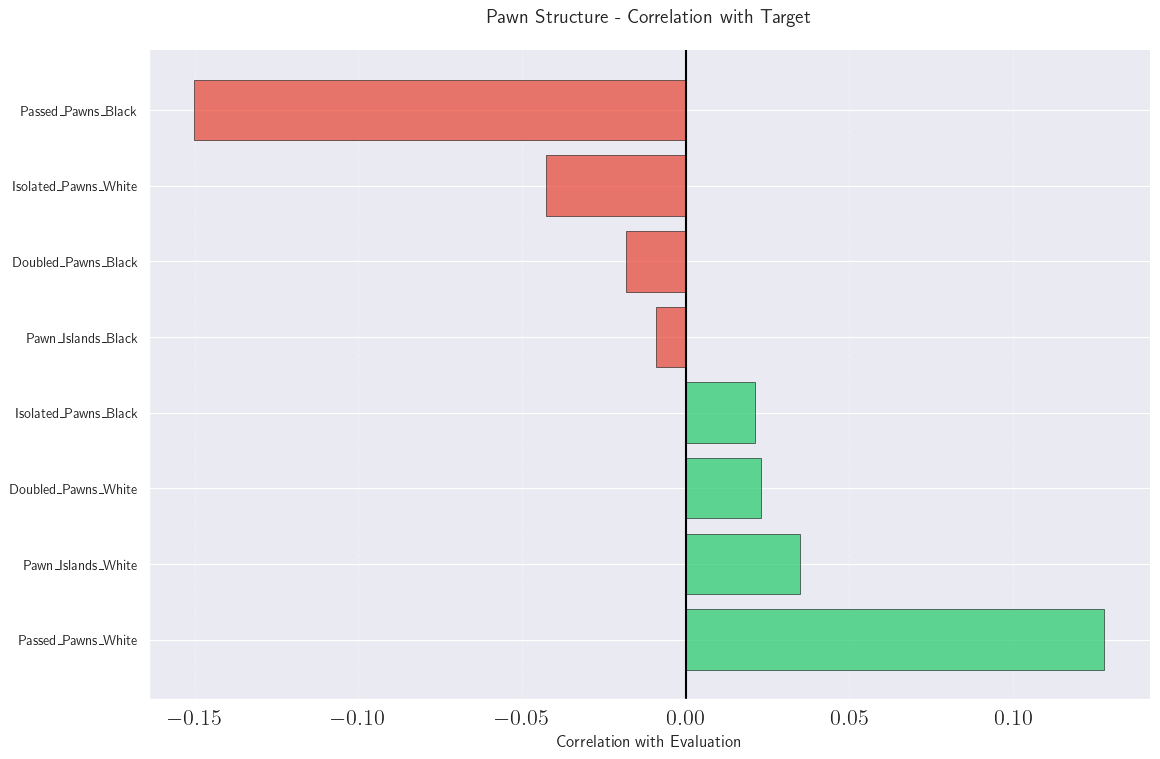

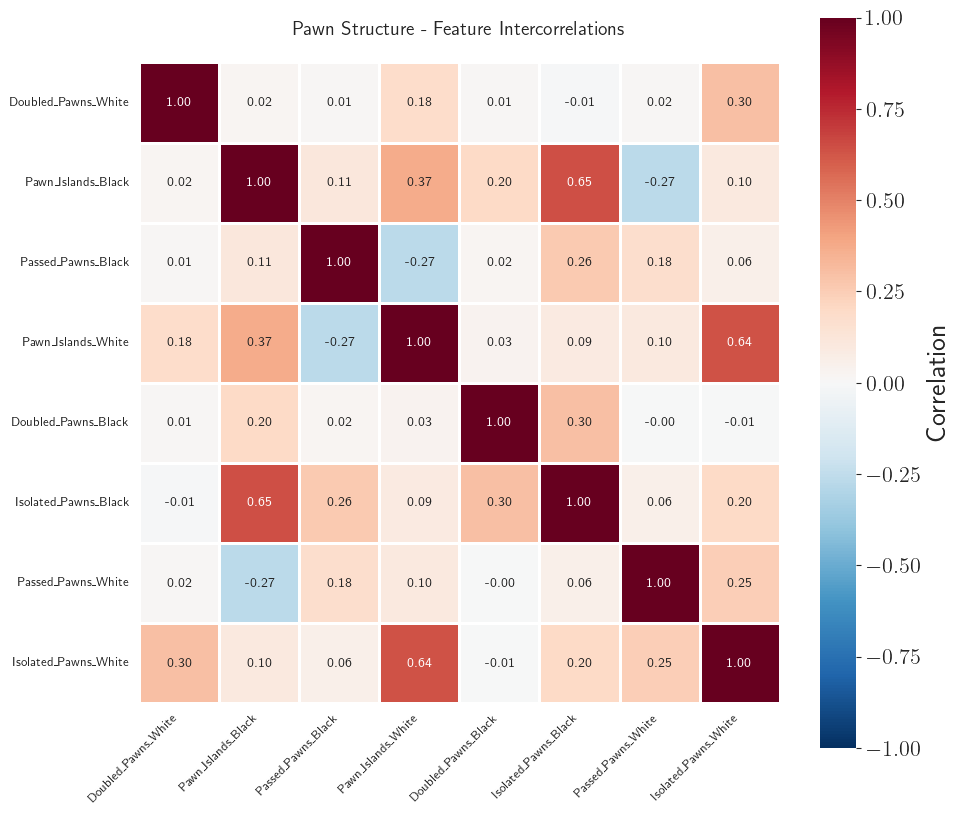



Feature Statistics:

                         mean       std  min  max
Doubled_Pawns_White   0.13240  0.356863  0.0  3.0
Pawn_Islands_Black    2.12008  0.679769  0.0  4.0
Passed_Pawns_Black    0.20931  0.526063  0.0  5.0
Pawn_Islands_White    2.13582  0.688460  0.0  4.0
Doubled_Pawns_Black   0.15421  0.377797  0.0  3.0
Isolated_Pawns_Black  0.69087  0.947131  0.0  6.0
Passed_Pawns_White    0.19504  0.507052  0.0  5.0
Isolated_Pawns_White  0.69669  0.938553  0.0  6.0


Feature Intercorrelation Matrix:

                      Doubled_Pawns_White  Pawn_Islands_Black  Passed_Pawns_Black  Pawn_Islands_White  Doubled_Pawns_Black  Isolated_Pawns_Black  Passed_Pawns_White  Isolated_Pawns_White
Doubled_Pawns_White                 1.000               0.019               0.013               0.183                0.013                -0.011               0.015                 0.298
Pawn_Islands_Black                  0.019               1.000               0.114               0.371                

In [5]:
# Apply PawnStructure transformer
dm.apply_transformers([PawnStructure])

# Analyze features
analyze_features(dm, PawnStructure)

### Observations on Pawn Structure Features

**1. Correlation with Evaluation**  
The pawn structure features show slightly stronger signals than raw piece counts, though still generally weak:

- **Passed_Pawns_Black** (-0.150) — most negatively correlated, suggesting that Black having passed pawns slightly lowers evaluation.  
- **Passed_Pawns_White** (0.128) — strongest positive effect, meaning White passed pawns slightly improve evaluation.  
- Other features have minimal correlations (|r| < 0.05), including isolated and doubled pawns for both colors.  

Overall, **pawn structure alone is not strongly predictive**, but passed pawns seem to carry the most weight, aligning with chess intuition about pawn potential.

---

**2. Feature Statistics**  
The dataset is clean and behaves as expected:

- **Pawn counts** are in reasonable ranges: 0–5 for passed pawns, 0–3 for doubled pawns, 0–6 for isolated pawns, and 0–4 for pawn islands.  
- **Means** indicate typical midgame structures: around 0.2–0.7 for passed or isolated pawns, and ~2 pawn islands per side.  
- **Standard deviations** show enough variability for modeling, without extreme outliers.  

---

**3. Intercorrelation Insights**  
The correlations between pawn features reveal a few interesting patterns:

- **Moderate correlations** appear between related features:  
  - `Isolated_Pawns_White` & `Pawn_Islands_White` (0.64) — as expected, more isolated pawns create more pawn islands.  
  - `Isolated_Pawns_Black` & `Pawn_Islands_Black` (0.648) — same pattern mirrored for Black.  
- **Weak or near-zero correlations** dominate otherwise, meaning most features are largely independent.  
- No pairs are perfectly redundant, suggesting each pawn metric captures slightly different aspects of structure.
---

**Summary**  
Pawn structure features are **mildly informative**, with passed pawns being the clearest contributors to evaluation shifts. Most other features are weakly correlated and fairly independent, providing complementary signals without major redundancy.

## 3. King Safety

**Pawns located near the king are the pillar of king safety.** We all know that *the more, the merrier*—the more pawns you have near your king, the safer and better protected he is.

The `KingSafety` transformer extracts:

- **Castling status**: Whether the king has castled (reached safety)
- **Pawn shield**: Number of pawns surrounding the king
- **Open files**: Files without pawns (potential attack routes)
- **King exposure**: Distance to back rank, attacked neighboring squares
- **Castling rights**: Whether castling is still possible
- **King in check**: Whether the king is currently under attack

King safety is crucial in the middlegame when attacks are most dangerous.


King Safety
15 features

Correlation with Evaluation (sorted by absolute value):

  King_Attacked_Neighbours_White           -0.112
  King_Attacked_Neighbours_Black            0.085
  King_Front_Pawns_White                    0.069
  King_Pawns_White                          0.069
  King_Pawns_Black                         -0.061
  King_Distance_to_Last_Rank_Black          0.050
  King_In_Check_White                      -0.049
  King_Front_Pawns_Black                   -0.044
  King_In_Check_Black                       0.037
  Open_Files                               -0.032
  King_Castled_Black                        0.026
  King_Castled_White                       -0.018
  King_Castling_Rights_Black                0.016
  King_Distance_to_Last_Rank_White          0.008
  King_Castling_Rights_White                0.003


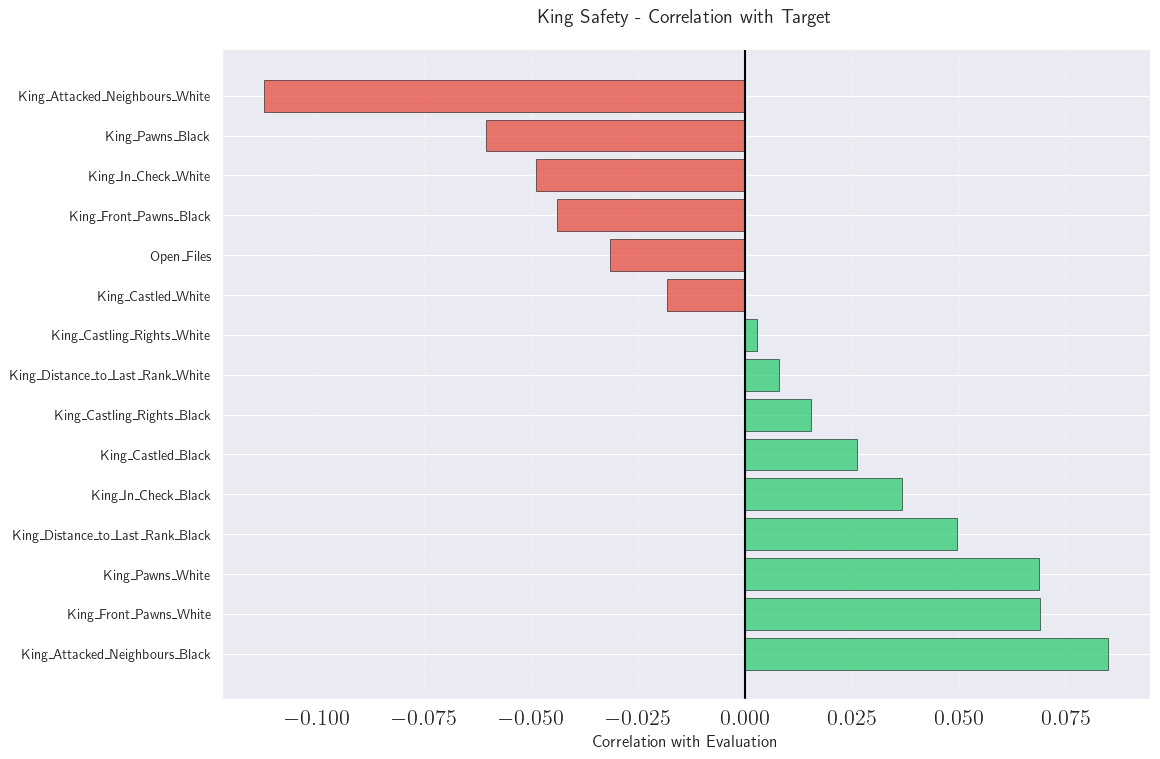

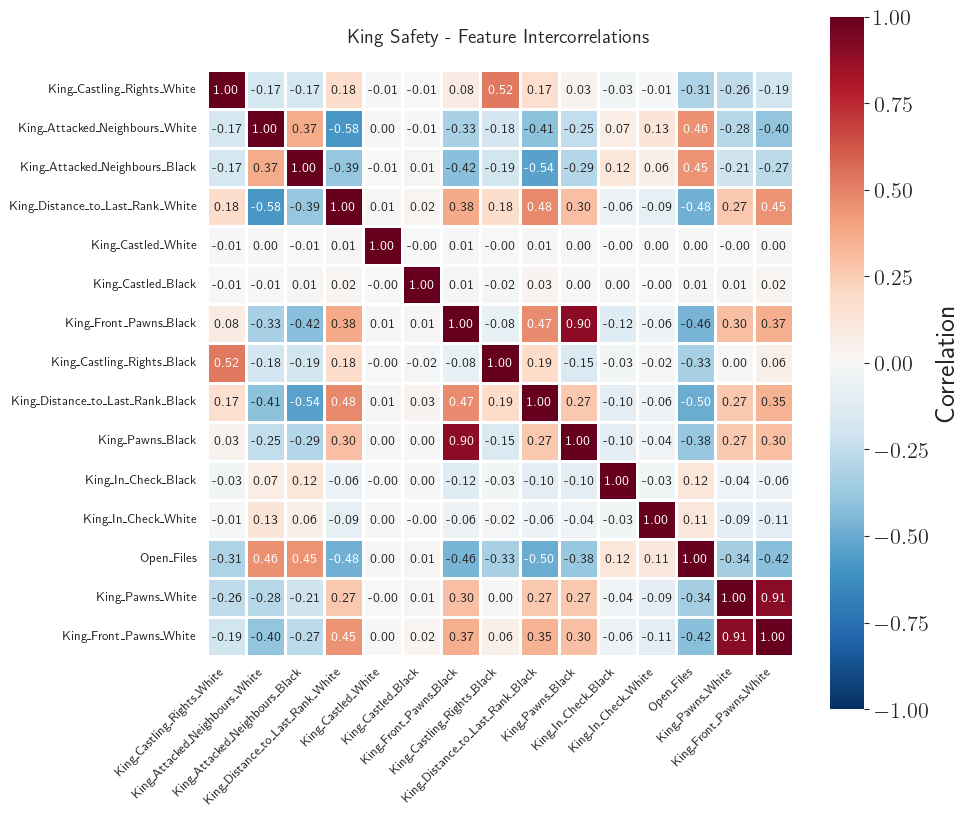



Feature Statistics:

                                     mean       std  min  max
King_Castling_Rights_White        0.11146  0.314702  0.0  1.0
King_Attacked_Neighbours_White    1.04584  1.371516  0.0  8.0
King_Attacked_Neighbours_Black    1.13748  1.377940  0.0  8.0
King_Distance_to_Last_Rank_White  6.48075  0.997998  0.0  7.0
King_Castled_White                0.00077  0.027738  0.0  1.0
King_Castled_Black                0.00275  0.052369  0.0  1.0
King_Front_Pawns_Black            1.35395  0.939403  0.0  3.0
King_Castling_Rights_Black        0.12995  0.336250  0.0  1.0
King_Distance_to_Last_Rank_Black  6.52640  0.939432  0.0  7.0
King_Pawns_Black                  1.51187  0.906183  0.0  4.0
King_In_Check_Black               0.02974  0.169870  0.0  1.0
King_In_Check_White               0.02718  0.162608  0.0  1.0
Open_Files                        3.77825  1.968257  0.0  8.0
King_Pawns_White                  1.41588  0.925458  0.0  4.0
King_Front_Pawns_White            1.26499  0.95

In [6]:
# Apply KingSafety transformer
dm.apply_transformers([KingSafety])

# Analyze features
analyze_features(dm, KingSafety)

### Observations on King Safety Features

**1. Correlation with Evaluation**  
King safety features show mostly weak correlations with evaluation, though a few stand out:

- **King_Attacked_Neighbours_White** (-0.112) — the most negatively correlated, indicating White’s king being under threat slightly lowers evaluation.  
- **King_Attacked_Neighbours_Black** (0.085) — opposite effect for Black; more attacked neighbors slightly increase evaluation.  
- **King_Front_Pawns_White** and **King_Pawns_White** (0.069 each) — slightly positive, suggesting White’s pawn shield provides a minor evaluation boost.  
- Other features, including castling status and checks, have very low correlations (|r| < 0.05), showing weak individual predictive power.

Overall, **King safety alone is not strongly predictive**, but threats to the king and the pawn shield seem to carry small but meaningful signals.

---

**2. Feature Statistics**  
The dataset appears well-structured and consistent:

- **Castling rights** are mostly 0/1 flags, with means around 0.11–0.13, reflecting that most kings have already castled in these positions.  
- **Distance to last rank** ranges 0–7, with means ~6.5, indicating kings are generally on or near their starting ranks.  
- **Pawn shields** average 1–1.4 pawns in front of each king, standard deviations show reasonable variability.  
- **King attack indicators** (attacked neighbors) vary widely from 0–8, allowing modeling of threat intensity.  

---

**3. Intercorrelation Insights**  
Some interesting relationships appear among king features:

- **High correlations**:  
  - `King_Front_Pawns_Black` & `King_Pawns_Black` (0.898) — expected, as front pawns strongly determine total pawn count around the king.  
  - `King_Front_Pawns_White` & `King_Pawns_White` (0.905) — same for White.  
- **Negative correlations** reflect defensive trade-offs:  
  - `King_Attacked_Neighbours_Black` & `King_Distance_to_Last_Rank_Black` (-0.541) — black kings closer to their home rank face fewer neighboring attacks, reflecting that king safety increases when the king stays back, which aligns with typical midgame positions.
- Most other correlations are low or moderate, showing features capture different aspects of king safety without heavy redundancy.  

---

**Summary**  
King safety features provide **small but interpretable signals**: attacks on the king and pawn shield strength matter slightly for evaluation. Most other features, like castling flags or checks, show weak individual effects, implying that king safety is more subtle and likely interacts with other positional or tactical elements in determining evaluation.


## 4. Piece Mobility

In chess, **the mobility of pieces is a crucial factor** because if a piece has no mobility, it is useless to the player. A bishop trapped behind its own pawns or a knight stuck in a corner contributes nothing to the position.

The `Mobility` transformer counts the number of legal moves available to each piece type:
- King, Queen, Rook, Bishop, Knight, and Pawn mobility for both colors
- Higher mobility generally indicates better piece coordination and control

Mobility reflects how active and well-placed pieces are.


Piece Mobility
12 features

Correlation with Evaluation (sorted by absolute value):

  Mobility_Pawn_White                       0.129
  Mobility_Bishop_White                     0.123
  Mobility_Rook_White                       0.115
  Mobility_Pawn_Black                      -0.115
  Mobility_Queen_White                      0.113
  Mobility_King_Black                      -0.108
  Mobility_Rook_Black                      -0.105
  Mobility_Knight_White                     0.094
  Mobility_Bishop_Black                    -0.094
  Mobility_King_White                       0.092
  Mobility_Queen_Black                     -0.084
  Mobility_Knight_Black                    -0.076


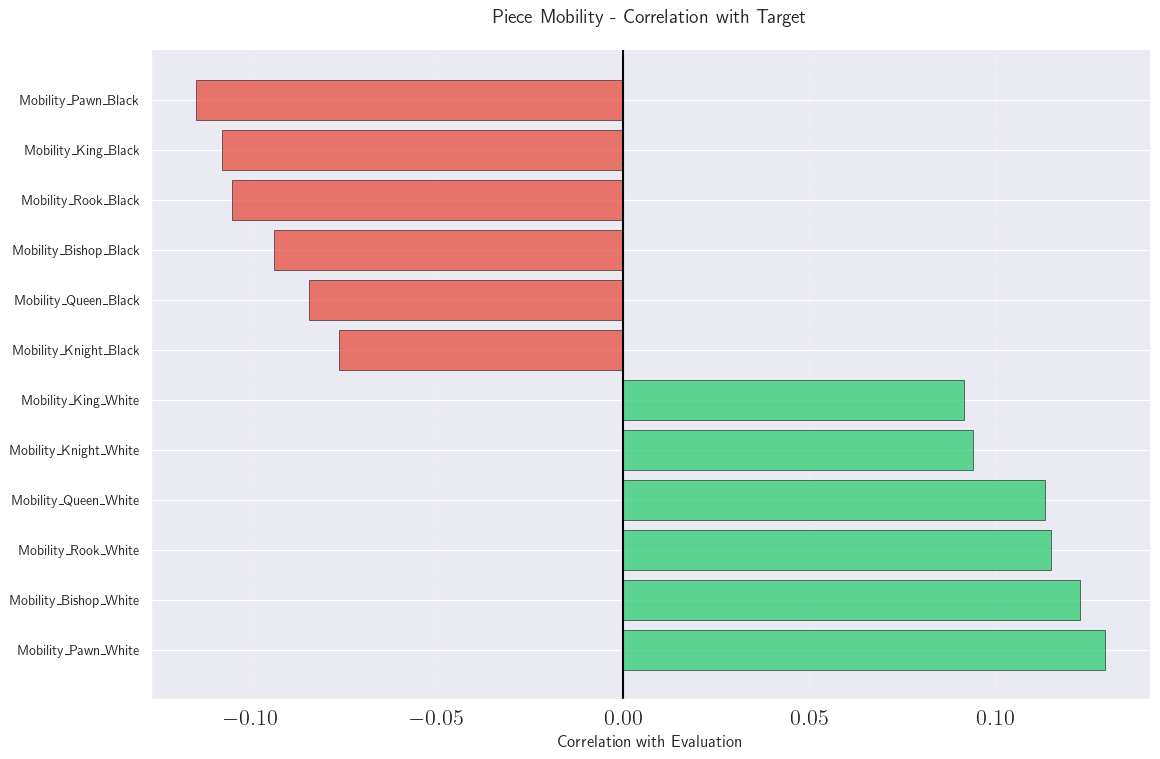

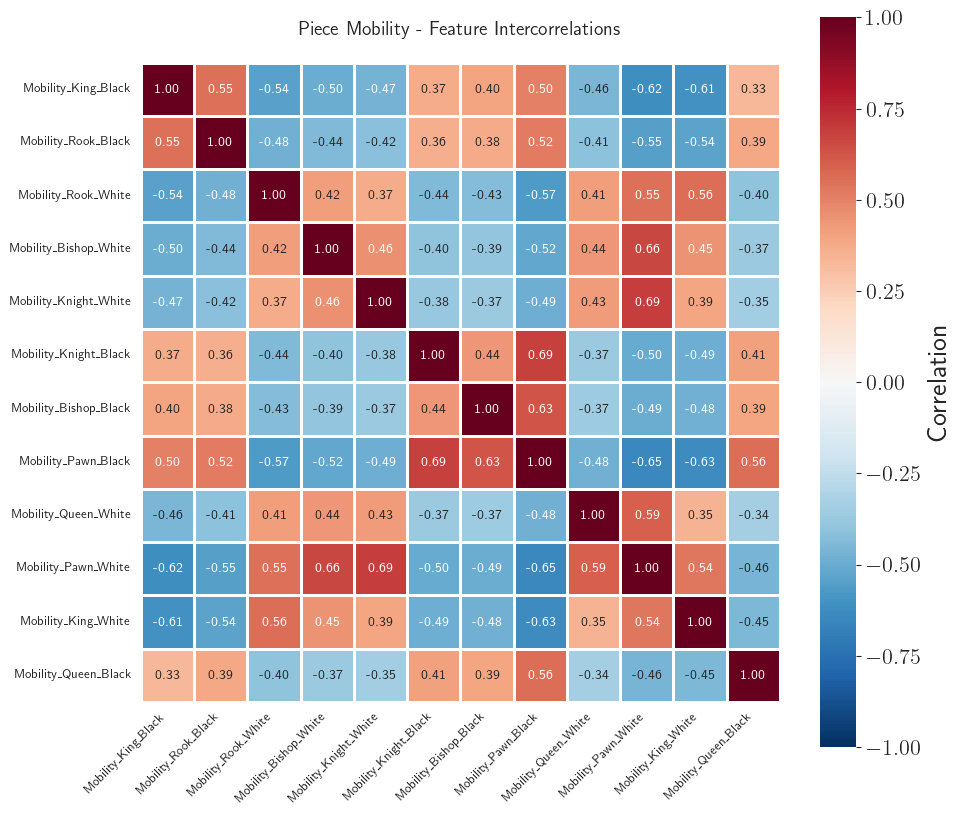



Feature Statistics:

                          mean       std  min   max
Mobility_King_Black    1.31148  1.691328  0.0   8.0
Mobility_Rook_Black    3.48994  5.071922  0.0  28.0
Mobility_Rook_White    3.80315  5.414450  0.0  28.0
Mobility_Bishop_White  2.72526  4.264666  0.0  22.0
Mobility_Knight_White  2.19484  3.629200  0.0  16.0
Mobility_Knight_Black  2.31278  3.686891  0.0  16.0
Mobility_Bishop_Black  2.44161  3.952904  0.0  24.0
Mobility_Pawn_Black    2.99346  3.705652  0.0  16.0
Mobility_Queen_White   3.06986  5.186022  0.0  40.0
Mobility_Pawn_White    2.94955  3.684443  0.0  17.0
Mobility_King_White    1.39054  1.778733  0.0   8.0
Mobility_Queen_Black   2.87204  4.982679  0.0  27.0


Feature Intercorrelation Matrix:

                       Mobility_King_Black  Mobility_Rook_Black  Mobility_Rook_White  Mobility_Bishop_White  Mobility_Knight_White  Mobility_Knight_Black  Mobility_Bishop_Black  Mobility_Pawn_Black  Mobility_Queen_White  Mobility_Pawn_White  Mobility_King_White  Mo

In [7]:
# Apply Mobility transformer
dm.apply_transformers([Mobility])

# Analyze features
analyze_features(dm, Mobility)

### Observations on Piece Mobility Features

**1. Correlation with Evaluation**  
Piece mobility features show slightly stronger correlations with evaluation compared to king safety:

- **Mobility_Pawn_White** (0.129), **Mobility_Bishop_White** (0.123), and **Mobility_Rook_White** (0.115) — the highest positive correlations, suggesting that greater mobility of White’s pieces slightly increases evaluation.  
- **Mobility_Pawn_Black** (-0.115) and **Mobility_King_Black** (-0.108) — negative correlations, indicating that higher mobility for Black pieces slightly lowers evaluation.  
- Other features, like knights and queens, have smaller correlations (|r| < 0.10), showing moderate individual predictive power.

Overall, **higher mobility of White pieces tends to improve evaluation**, while mobility of some Black pieces has the opposite effect, reflecting the typical advantage of the side to move or attacking side in the dataset.

---

**2. Feature Statistics**  
The dataset appears well-structured and consistent:

- Mobility counts vary widely across pieces, with **means ranging from 1.3 (King_Black) to ~3.8 (Rook_White)** and maximums up to 40 (Queen_White).  
- Standard deviations are relatively high, reflecting variability in possible moves depending on board position.  
- All features are non-negative and provide sufficient spread for modeling piece activity.

---

**3. Intercorrelation Insights**  
The intercorrelation matrix reveals clear patterns:

- **Within-color correlations**:  
  - Mobility of pawns, bishops, and rooks on the same side are often positively correlated (e.g., Mobility_Pawn_White & Mobility_Bishop_White = 0.664), reflecting that positions with more open movement for one piece type tend to have higher mobility for other pieces.  
- **Cross-color correlations**:  
  - Negative correlations between White and Black piece mobilities (e.g., Mobility_Pawn_White & Mobility_Pawn_Black = -0.647) suggest that when one side has more mobility, the opponent often has less, reflecting opposing control of space.  
- **Kings’ mobility**:  
  - It is clearly illustrated that the mobility of the king correlates with the mobility of the other pieces: if Black pieces have higher mobility, the Black king tends to have lower mobility, and vice versa.
- Most other correlations are moderate, showing features capture different aspects of mobility without excessive redundancy.

---

**Summary**  
Piece mobility features provide **interpretable signals for evaluation**: higher mobility for White generally corresponds to higher evaluation, while mobility for Black often has the opposite effect.

## 5. Board Control

The `BoardControl` class encodes **essential positional factors that material alone cannot capture**. Control of central squares, open and semi-open files, rook placement, protected advanced pawns, piece alignment, and total controlled squares all describe how active, coordinated, and dominant each side's pieces are.

These concepts directly influence long-term strategic advantages:
- **Space**: Control of key squares limits opponent options
- **Mobility**: Open files and ranks enable piece activity
- **Initiative**: Better control allows attacking chances
- **Coordination**: Aligned rooks and centralized pieces work together

Features include:
- Central square control (d4, d5, e4, e5)
- Open and semi-open columns
- Rooks on open files
- Protected advanced pawns
- Piece alignments (rook-queen, rook-rook)
- Total controlled squares


Board Control
15 features

Correlation with Evaluation (sorted by absolute value):

  Controlled_Squares_White                  0.159
  SemiOpen_Columns_Black                    0.152
  SemiOpen_Columns_White                   -0.150
  Central_Squares_Control_White             0.093
  Controlled_Squares_Black                 -0.079
  Central_Squares_Control_Black            -0.071
  Rook_on_Open_Column_Black                -0.067
  Protected_Advanced_Pawn_White             0.061
  Rook_on_Open_Column_White                 0.049
  Rooks_Aligned_White                       0.040
  Open_Columns                             -0.038
  Rook_Queen_Aligned_Black                  0.035
  Rook_Queen_Aligned_White                  0.024
  Protected_Advanced_Pawn_Black            -0.023
  Rooks_Aligned_Black                       0.018


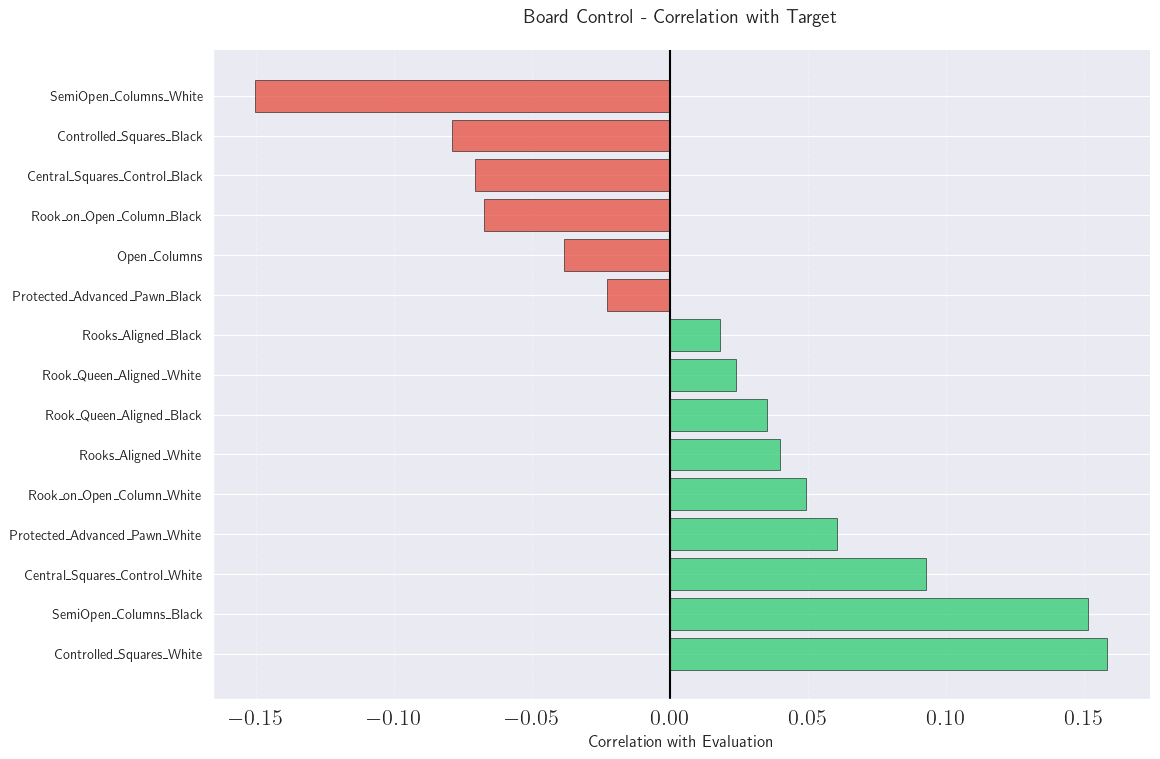

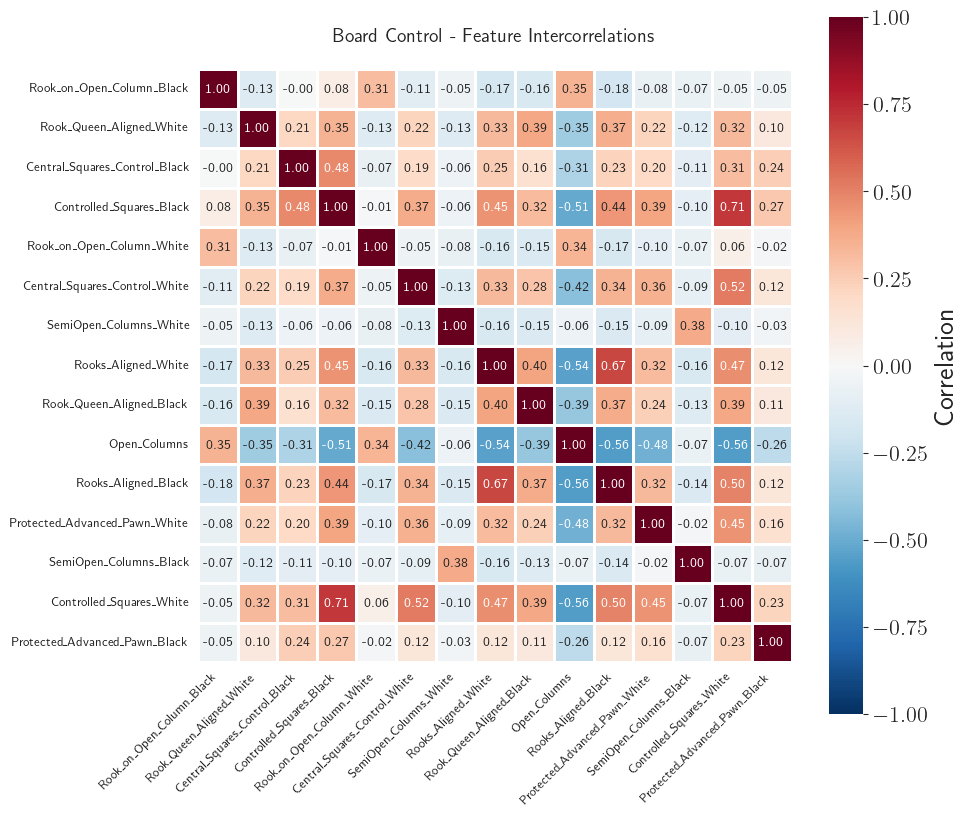



Feature Statistics:

                                   mean       std  min   max
Rook_on_Open_Column_Black       0.29761  0.457209  0.0   1.0
Rook_Queen_Aligned_White        0.28847  0.453053  0.0   1.0
Central_Squares_Control_Black   2.73621  0.975097  0.0   4.0
Controlled_Squares_Black       32.14597  6.396536  4.0  50.0
Rook_on_Open_Column_White       0.31763  0.465557  0.0   1.0
Central_Squares_Control_White   2.87604  1.008040  0.0   4.0
SemiOpen_Columns_White          1.13466  0.838376  0.0   5.0
Rooks_Aligned_White             0.49219  0.499941  0.0   1.0
Rook_Queen_Aligned_Black        0.31721  0.465392  0.0   1.0
Open_Columns                    1.55734  1.529306  0.0   8.0
Rooks_Aligned_Black             0.50790  0.499940  0.0   1.0
Protected_Advanced_Pawn_White   0.76428  0.424450  0.0   1.0
SemiOpen_Columns_Black          1.08625  0.805430  0.0   5.0
Controlled_Squares_White       33.06152  6.662331  3.0  50.0
Protected_Advanced_Pawn_Black   0.62065  0.485228  0.0   1.0



In [8]:
# Apply BoardControl transformer
dm.apply_transformers([BoardControl])

# Analyze features
analyze_features(dm, BoardControl)

### Observations of Board Control Features 

**1. Correlation with Evaluation**  
- **Controlled_Squares_White** (0.159) — the more squares White controls, the higher the evaluation, indicating a stronger potential to win.  
- **SemiOpen_Columns_Black** (0.152) — these positively correlate with White’s evaluation, which is not surprising: Black having semi-open columns often arises when White has advanced pawns or open lines, limiting Black’s effective activity while giving White more dynamic possibilities.  
- **SemiOpen_Columns_White** (-0.150) — more semi-open columns for White slightly reduce evaluation, reflecting that open files can indicate pawn structure weaknesses or potential targets for Black.  
- **Central_Squares_Control_White** (0.093) — central dominance provides a modest but meaningful boost to White’s win potential.  
- **Controlled_Squares_Black** (-0.079) and **Central_Squares_Control_Black** (-0.071) — when Black controls more squares or the center, the evaluation slightly favors White, showing that these metrics alone are insufficient to overturn White’s overall spatial advantage.  

Overall, **White’s control of the board, especially in the center and across key squares, strongly contributes to its winning potential, while semi-open columns reflect nuanced tactical and structural trade-offs that align with typical middlegame patterns**, highlighting how control metrics capture both advantages and vulnerabilities on the board.

---

**2. Feature Statistics**  
- **Square control**: White averages ~33 squares, Black ~32; small difference, but higher square control favors White.  
- **Central squares**: White ~2.88, Black ~2.74 — slight edge for White in the center.  
- **Rook and pawn metrics** mostly binary (0–1), reflecting tactical setups like aligned rooks or protected pawns.  
- **Semi-open and open columns** vary moderately (0–5 or 0–8), representing opportunities for rook activity and tactical play.

---

**3. Intercorrelation Patterns**  
- **Related metrics correlate moderately**:  
  - `Controlled_Squares_White` & `Central_Squares_Control_White` (0.522) — central control contributes significantly to overall square dominance.  
  - `Controlled_Squares_Black` & `Central_Squares_Control_Black` (0.482) — same for Black.  
- **Trade-offs appear**: `Open_Columns` negatively correlates with `Controlled_Squares_White` (-0.561), suggesting positions with more open lines may reduce general control.  
- Other features are weakly correlated, capturing different aspects of board control with minimal redundancy.

---

**Summary**  
Overall, board control shows that White’s got the edge when they control more squares and the center, while Black’s influence tends to align with White’s advantage; semi-open columns make total sense too—White’s can be a sign of weak pawns or open targets, and Black’s usually appear in positions where White dominates anyway—so it’s really just a reflection of how the position shapes up, giving a good sense of who’s likely in charge on the board.


## 6. Attack and Tactical Relations

In chess, **relations such as threats created, hanging pieces, and undefended pieces are important** because they show tactical opportunities, immediate risks, and positional weaknesses. By counting them and weighting them in points, they provide a clear measure of material and strategic advantage.

The `Attack` transformer captures:
- **Threats created**: Enemy pieces under attack
- **Hanging pieces**: Pieces attacked but not defended (critical weakness)
- **Hanging points**: Material value of hanging pieces
- **Undefended pieces**: All pieces lacking protection (potential targets)
- **Undefended points**: Total material value of undefended pieces

These are tactical features that can dramatically change position evaluation.


Relations
10 features

Correlation with Evaluation (sorted by absolute value):

  Threats_Created_White                     0.046
  Undefended_Pieces_Black                  -0.033
  Undefended_Pieces_White                   0.033
  Undefended_Points_White                   0.022
  Hanging_Pieces_Black                      0.015
  Hanging_Pieces_White                     -0.014
  Threats_Created_Black                     0.013
  Undefended_Points_Black                  -0.010
  Hanging_Points_White                     -0.002
  Hanging_Points_Black                      0.001


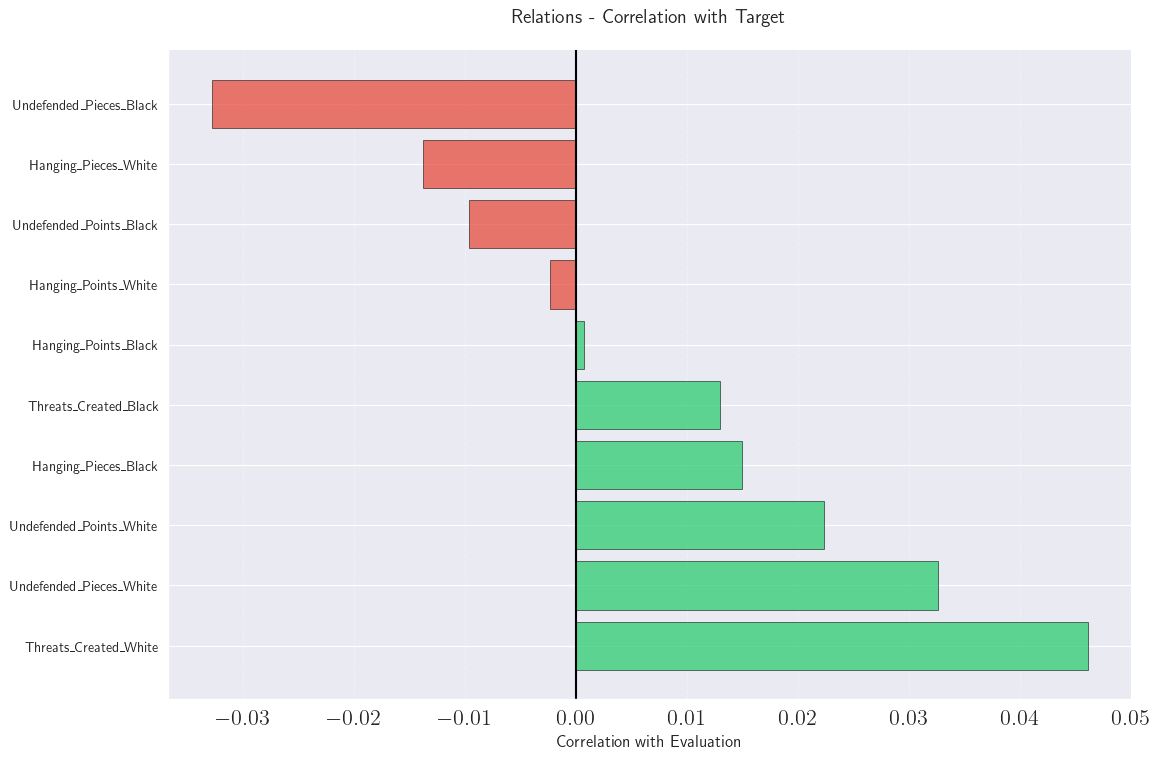

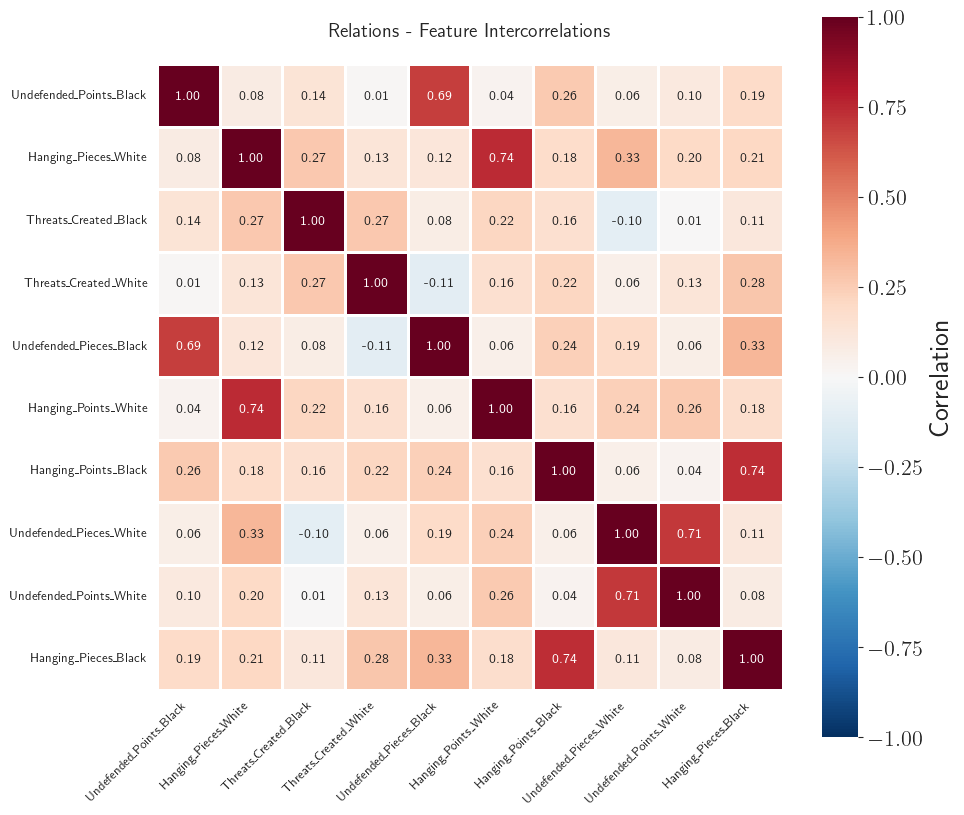



Feature Statistics:

                            mean       std  min   max
Undefended_Points_Black  6.60137  4.741258  0.0  29.0
Hanging_Pieces_White     0.26803  0.525826  0.0   5.0
Threats_Created_Black    2.04630  1.339072  0.0   9.0
Threats_Created_White    1.95623  1.303944  0.0   8.0
Undefended_Pieces_Black  2.11655  1.241492  0.0   9.0
Hanging_Points_White     0.62231  1.655961  0.0  19.0
Hanging_Points_Black     0.60489  1.641720  0.0  21.0
Undefended_Pieces_White  2.14411  1.272084  0.0   9.0
Undefended_Points_White  6.66019  4.790446  0.0  30.0
Hanging_Pieces_Black     0.25691  0.512825  0.0   5.0


Feature Intercorrelation Matrix:

                         Undefended_Points_Black  Hanging_Pieces_White  Threats_Created_Black  Threats_Created_White  Undefended_Pieces_Black  Hanging_Points_White  Hanging_Points_Black  Undefended_Pieces_White  Undefended_Points_White  Hanging_Pieces_Black
Undefended_Points_Black                    1.000                 0.084                  0

In [9]:
# Apply Attack transformer
dm.apply_transformers([Attack])

# Analyze features
analyze_features(dm, Attack)

### Observations of Relations Features

**1. Correlation with Evaluation**  
- **Threats_Created_White** (0.046) — the more threats White creates, the slightly higher the evaluation, suggesting a small positive impact on winning potential.  
- **Undefended_Pieces_Black** (-0.033) — Black having undefended pieces slightly favors White, which makes sense since unprotected pieces are tactical liabilities.  
- **Undefended_Pieces_White** (0.033) — White having undefended pieces has a minor positive correlation with evaluation, possibly reflecting positions where White can afford minor risks due to overall advantage.  
- **Undefended_Points_White** (0.022) and **Hanging_Pieces_Black** (0.015) — these metrics are weakly predictive but generally align with the idea that material vulnerabilities influence evaluation in subtle ways.  
- Other features like hanging points and threats by Black show near-zero correlations, indicating that on their own they don’t strongly impact the overall evaluation.

Overall, **these relations metrics capture small tactical opportunities and vulnerabilities**: White creating threats and Black having undefended pieces slightly improve White’s evaluation, while most other metrics are minor signals, reflecting that single-piece or point-level imbalances matter less than overall positional control and structure.

---

**2. Feature Statistics**  
- **Threats**: White creates ~2 threats on average per position, Black ~2 as well — fairly balanced.  
- **Hanging / undefended pieces**: Both sides have ~2 undefended pieces on average and ~0.6 hanging points, showing typical middlegame risks without extreme imbalances.  
- **Ranges** are realistic: hanging points up to ~20, undefended points up to ~30, suggesting the dataset covers a wide variety of tactical positions.

---

**3. Intercorrelation Patterns**  
- **Strongest correlations**: Hanging_Pieces_White/Black & Hanging_Points_White/Black (0.74) — unsurprisingly, pieces and their point values move together. This occurs as well with the Undefended_Points_White/Black & Undefended_Pieces_White/Black.
- Other metrics correlate weakly, reflecting that threats, hanging pieces, and undefended points capture different tactical dimensions with minimal redundancy.

---

**Summary**  
In short, the relations features show that White gains a slight edge when creating threats and when Black has undefended pieces, while most other measures have very minor effects; it’s a subtle reminder that **small tactical factors matter, but they mostly complement broader positional advantages rather than overturn them**, giving a quick sense of where vulnerabilities and opportunities exist on the board.


## 7. Game Information

In this section, we address the **remaining features that are not grouped semantically**. The `GameInfo` transformer extracts:

- **Side to move**: White or black to play (tempo advantage)
- **Fullmove number**: How many moves have been played
- **Halfmove clock**: Moves since last capture or pawn advance (50-move rule)
- **Game phase**: Ratio of remaining material (opening vs endgame)
- **En passant availability**: Special pawn capture opportunity

These features provide context about the game state that affects evaluation.


Game Info
5 features

Correlation with Evaluation (sorted by absolute value):

  Side_To_Move_White                        0.095
  Phase                                     0.049
  Fullmove_Number                          -0.028
  Halfmove_Clock                           -0.012
  Has_En_Passant                            0.008


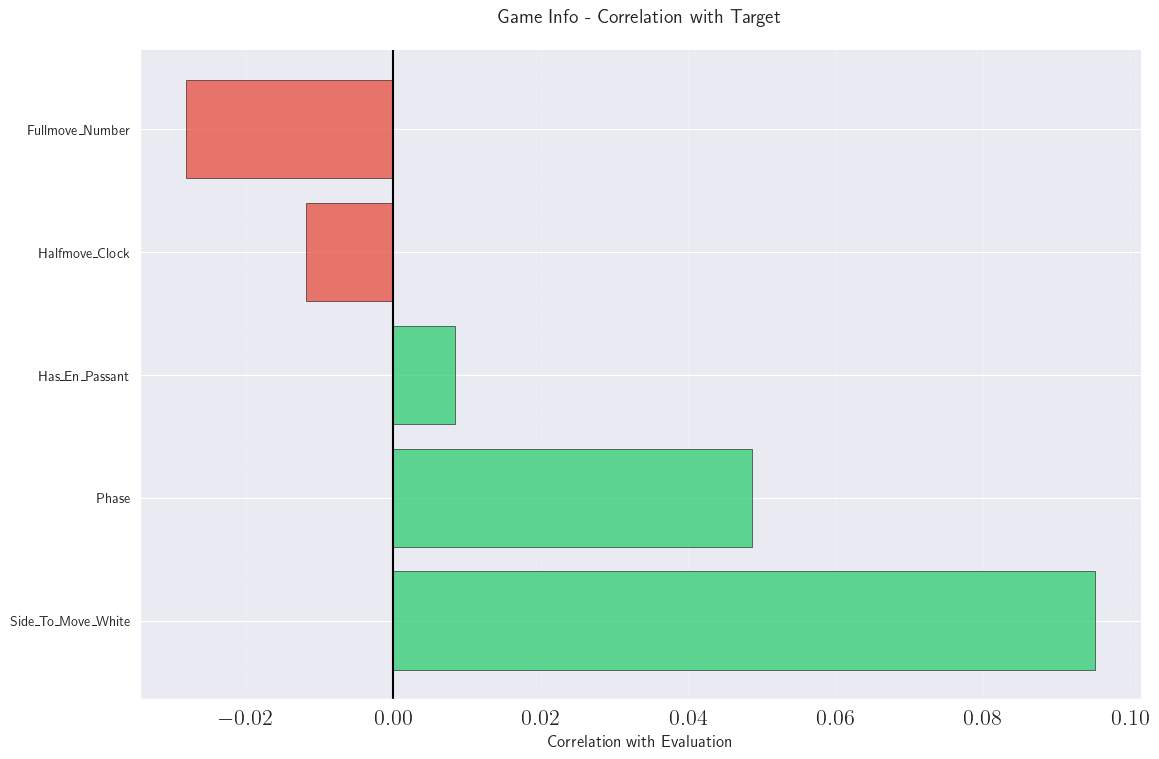

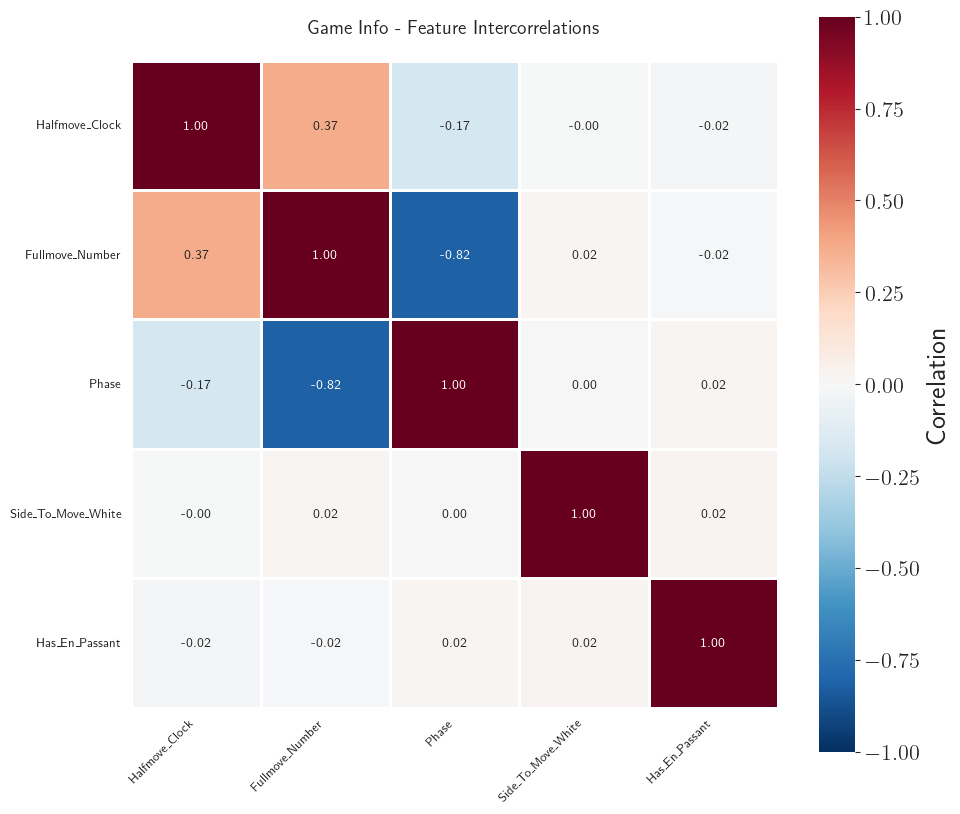



Feature Statistics:

                         mean        std  min    max
Halfmove_Clock       2.436170   4.696512  0.0  100.0
Fullmove_Number     27.904850  15.034164  1.0  165.0
Phase                0.639103   0.261381  0.0    1.0
Side_To_Move_White   0.496890   0.499993  0.0    1.0
Has_En_Passant       0.001810   0.042506  0.0    1.0


Feature Intercorrelation Matrix:

                    Halfmove_Clock  Fullmove_Number  Phase  Side_To_Move_White  Has_En_Passant
Halfmove_Clock               1.000            0.375 -0.174              -0.000          -0.022
Fullmove_Number              0.375            1.000 -0.819               0.016          -0.015
Phase                       -0.174           -0.819  1.000               0.001           0.019
Side_To_Move_White          -0.000            0.016  0.001               1.000           0.024
Has_En_Passant              -0.022           -0.015  0.019               0.024           1.000




In [10]:
# Apply GameInfo transformer
dm.apply_transformers([GameInfo])

# Analyze features
analyze_features(dm, GameInfo)

### Observations of Game Info Features

**1. Correlation with Evaluation**  
- **Side_To_Move_White** (0.095) — having the move gives White a small but real bump, basically the usual tempo advantage.  
- **Phase** (0.049) — later-stage positions lean a bit toward White in this dataset, likely because simplified positions often favor the stronger side.  
- **Fullmove_Number** (-0.028) — deeper into the game slightly correlates with worse eval for White, but it’s tiny and probably more about game flow than substance.  
- **Halfmove_Clock** (-0.012) and **Has_En_Passant** (0.008) — these are basically non-signals.

Overall, these are **context features more than predictors**—they describe the stage and rhythm of the game but don’t strongly sway evaluation on their own.

---

**2. Feature Statistics**  
- **Side to move** is basically 50/50, as expected.  
- **Phase** averages ~0.64, so the dataset leans toward mid-to-late game positions.  
- **Fullmove number** averages ~28 but goes up to 165, showing lots of long games.  
- **Halfmove clock** is low on average (~2.4) but can spike, capturing quiet stretches.  
- **En passant** is almost never available (~0.18%), so it’s basically a decorative feature.

---

**3. Intercorrelation Patterns**  
- **(Phase, Fullmove_Number)** (-0.819) — super strong, totally intuitive: early moves = opening, high move numbers = endgame.  
- **(Halfmove_Clock, Fullmove_Number)** (0.375) — later stages tend to have longer quiet streaks.  
- Everything else barely correlates with anything, so these features stay pretty independent.

---

**Summary**  
Game info features mainly set the scene (they tell you *where the game is*, not *who’s winning*). The only real nudge is the tempo boost for White; everything else is background context rather than a strong driver of evaluation.


## Overall Feature Correlation

Let's look at the overall correlation structure of all features with Evaluation.

In [11]:
all_feature_cols = [col for col in dm.df.columns if col not in [FEN, EVAL]]

eval_corr_all = dm.df[all_feature_cols + [EVAL]].corr()[EVAL].drop(EVAL).sort_values(ascending=False)

print("\nTop 20 Features Most Correlated with Evaluation:\n")
print(eval_corr_all.head(20).to_string())

print("\nTop 20 Features Most Negatively Correlated with Evaluation:\n")
print(eval_corr_all.tail(20).to_string())


Top 20 Features Most Correlated with Evaluation:

Controlled_Squares_White          0.158603
SemiOpen_Columns_Black            0.151689
Mobility_Pawn_White               0.129384
Passed_Pawns_White                0.128007
Mobility_Bishop_White             0.122704
Mobility_Rook_White               0.114944
Mobility_Queen_White              0.113316
White_Pawn                        0.112450
Side_To_Move_White                0.095322
Mobility_Knight_White             0.094010
Central_Squares_Control_White     0.092726
Mobility_King_White               0.091665
White_Pieces                      0.090911
King_Attacked_Neighbours_Black    0.084902
White_Central_Pieces              0.084817
White_Piece_Value                 0.075886
King_Front_Pawns_White            0.068989
King_Pawns_White                  0.068911
Protected_Advanced_Pawn_White     0.060723
White_Rook                        0.059261

Top 20 Features Most Negatively Correlated with Evaluation:

Undefended_Pieces_Black    

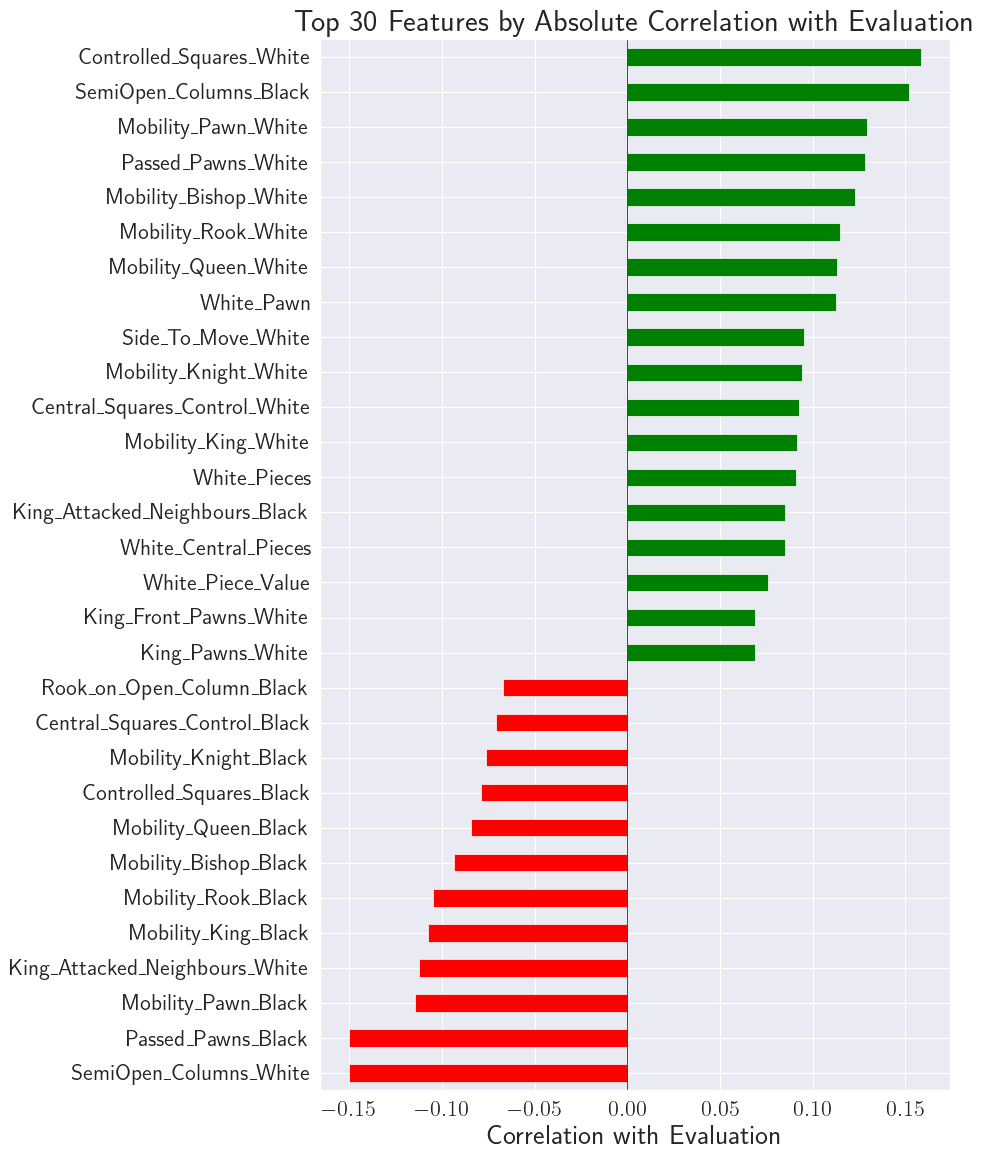

In [16]:
# Visualize top correlations
top_n = 30
top_features = eval_corr_all.loc[eval_corr_all.abs().sort_values(ascending=False).index].head(top_n).sort_values()

plt.figure(figsize=(10, 12))
colors = ['red' if x < 0 else 'green' for x in top_features]
top_features.plot(kind='barh', color=colors)
plt.xlabel('Correlation with Evaluation')
plt.title(f'Top {top_n} Features by Absolute Correlation with Evaluation')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

## Summary and Conclusions

We have systematically extracted and analyzed 7 categories of chess features:

1. **PieceInfo** (16 features): Material counts and values
2. **PawnStructure** (8 features): Pawn weaknesses and strengths
3. **KingSafety** (15 features): King protection and exposure
4. **Mobility** (12 features): Piece activity
5. **BoardControl** (15 features): Spatial advantage and coordination
6. **Attack** (10 features): Tactical threats and vulnerabilities
7. **GameInfo** (5 features): Game state context

**Total: 81 features**


### Decision: Keep All Features

**We will keep all 81 features for the following reasons:**

1. **Complementary information**: Different features capture different aspects of chess
2. **Non-linear interactions**: Even weakly correlated features may combine powerfully
3. **Model selection**: Advanced models such as XGBoost can handle many features
4. **Feature importance**: We can analyze which features models actually use
5. **No computational constraint**: Our dataset is manageable with 81 features